In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
SRC_ROOT = PROJECT_ROOT / "src"

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

In [2]:
import cv2
import matplotlib.pyplot as plt

from palmprint.preprocessing.roi import (
    RoiExtractionConfig,
    extract_hand_roi,
)

In [3]:
config = RoiExtractionConfig(
    use_clahe=True,
    clahe_clip_limit=2.0,
    clahe_tile_grid_size=(8, 8),
    blur_ksize=(7, 7),
    threshold_method="otsu",
    morph_kernel_size=(11, 11),
    morph_close_iterations=2,
    morph_open_iterations=1,
    morph_close_first=True,
    bbox_margin_frac=0.03,
    roi_crop_frac=0.55,
    crop_method="centroid",
    rotate_to_principal_axis=True,
    rotation_center="centroid",
)

In [7]:
def show_roi(image_path):
    img = cv2.imread(str(image_path))
    result = extract_hand_roi(img, config)

    roi = result.final_roi.image
    roi = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)

    plt.figure()
    plt.imshow(roi)
    plt.title(image_path.name)
    plt.axis("off")

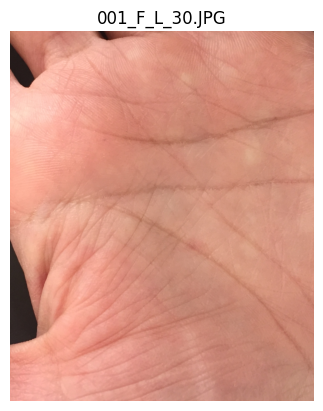

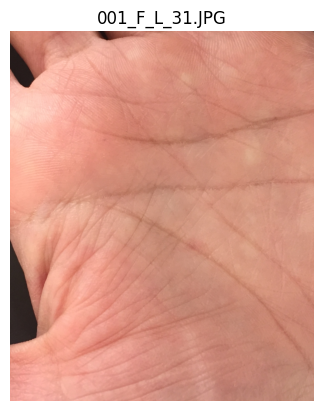

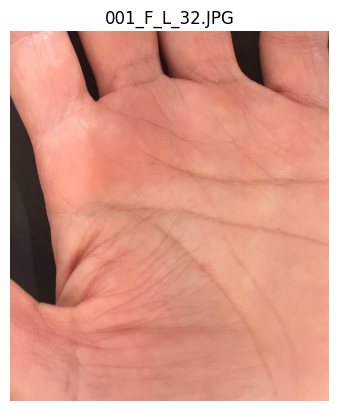

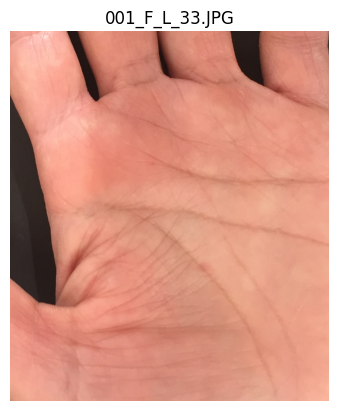

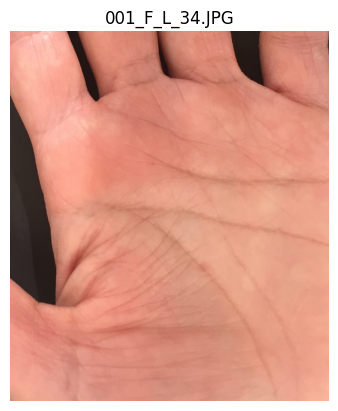

In [8]:
sample_dir = Path("../data/raw/bmpd/BMPD/001")
images = list(sample_dir.glob("*"))[:5]

for img_path in images:
    show_roi(img_path)

In [ ]:
input_root = Path("../data/raw/bmpd/BMPD")
output_root = Path("../data/processed/bmpd_roi")
roi_size = 224

output_root.mkdir(parents=True, exist_ok=True)

for subject_dir in sorted(input_root.iterdir()):
    if not subject_dir.is_dir():
        continue

    subject_output = output_root / subject_dir.name
    subject_output.mkdir(parents=True, exist_ok=True)

    for img_path in subject_dir.glob("*"):
        if img_path.suffix.lower() not in {".jpg", ".png", ".bmp"}:
            continue

        img = cv2.imread(str(img_path))

        try:
            result = extract_hand_roi(img, config)
            roi = result.final_roi.image

            roi_resized = cv2.resize(roi, (roi_size, roi_size))

            out_path = subject_output / f"{img_path.stem}_roi.png"
            cv2.imwrite(str(out_path), roi_resized)

        except Exception as e:
            print(f"Failed: {img_path} -> {e}")

In [9]:
processed_dir = Path("../data/processed/bmpd_roi/001")
list(processed_dir.glob("*"))[:5]

[WindowsPath('../data/processed/bmpd_roi/001/001_F_L_30_roi.png'),
 WindowsPath('../data/processed/bmpd_roi/001/001_F_L_31_roi.png'),
 WindowsPath('../data/processed/bmpd_roi/001/001_F_L_32_roi.png'),
 WindowsPath('../data/processed/bmpd_roi/001/001_F_L_33_roi.png'),
 WindowsPath('../data/processed/bmpd_roi/001/001_F_L_34_roi.png')]